**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [ ]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print(df.head())
print(df.info())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

**Check Missing Values**

In [ ]:
print(df.isnull().sum())

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


In [ ]:
df = df.dropna()

**Rename Columns**

In [ ]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


**Convert Date Column**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].head())

0   2020-01-31
1   2020-02-29
2   2020-03-31
3   2020-04-30
4   2020-05-31
Name: Date, dtype: datetime64[ns]


/tmp/ipykernel_2475/828552183.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


**Basic Statistics**

In [ ]:
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            267                       267.000000   
mean   2020-06-16 09:15:30.337078528                        12.236929   
min              2020-01-31 00:00:00                         0.500000   
25%              2020-03-31 00:00:00                         4.845000   
50%              2020-06-30 00:00:00                         9.650000   
75%              2020-08-31 00:00:00                        16.755000   
max              2020-10-31 00:00:00                        75.850000   
std                              NaN                        10.803283   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        2.670000e+02                               267.000000   
mean         1.396211e+07                                41.681573   
min          1.175420e+05                                16.770000   
25%          2.838930e+06                                37.26

**Unemployment Rate by State**

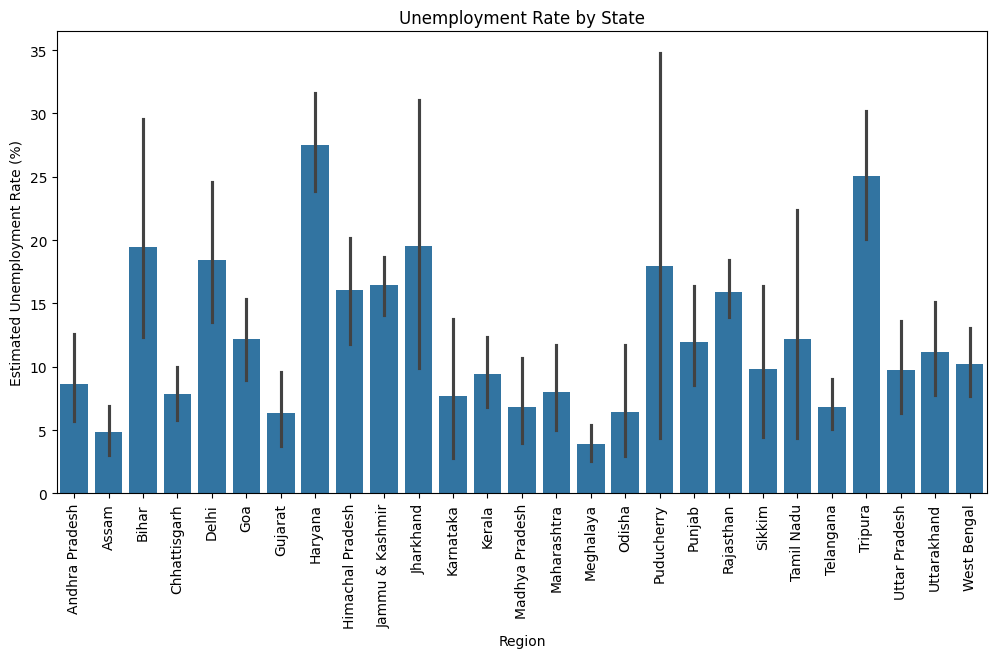

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Region',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.xticks(rotation=90)
plt.title("Unemployment Rate by State")
plt.show()

**Monthly Unemployment**

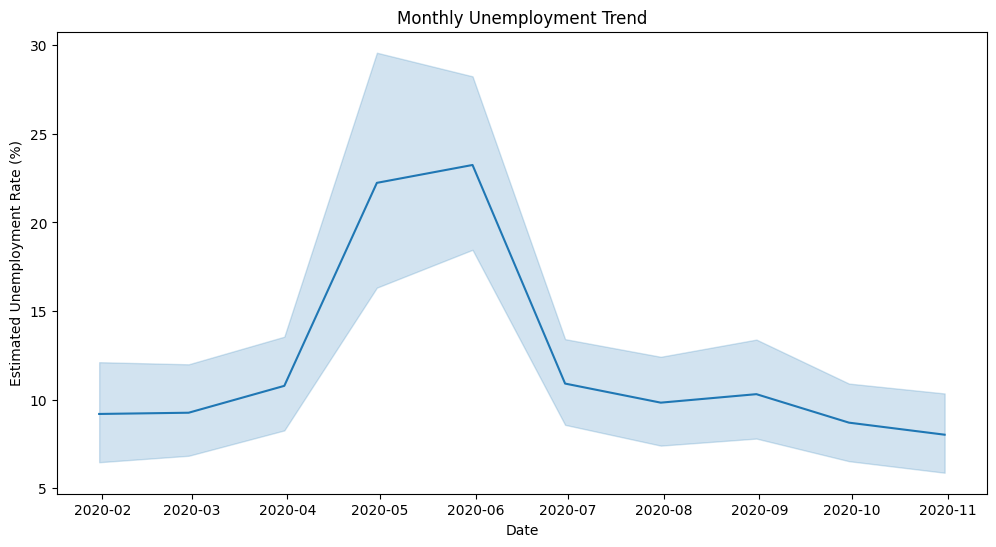

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Monthly Unemployment Trend")
plt.show()

**Highest Unemployment States**

In [ ]:
state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean()

print(state_unemployment.sort_values(ascending=False).head(10))

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64


**Correlation Heatmap**

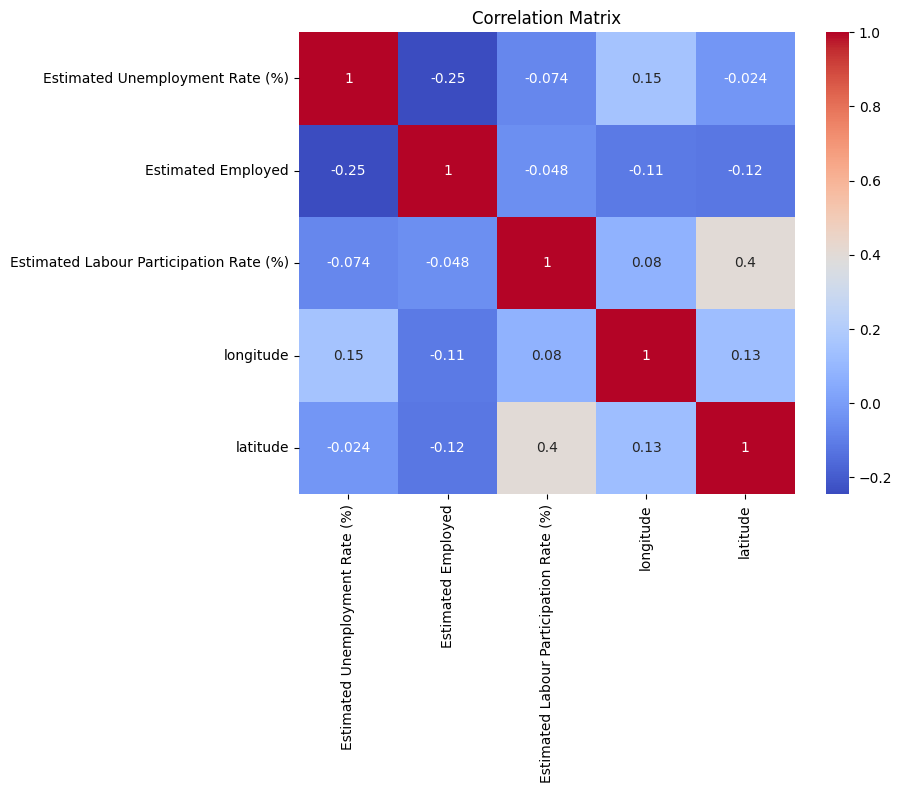

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

**COVID-19 Impact Analysis**

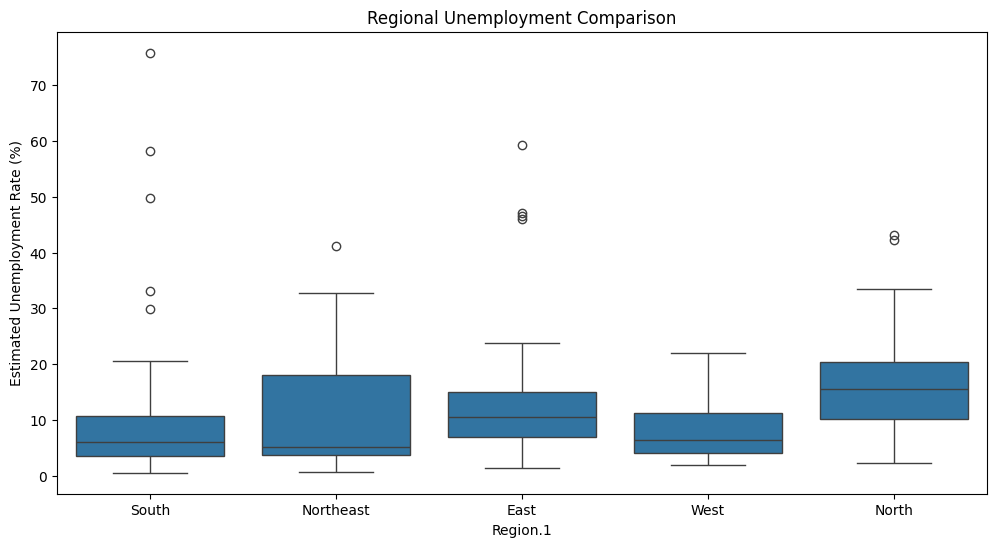

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Region.1',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Regional Unemployment Comparison")
plt.show()